In [42]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [43]:
import numpy as np
import numpy.random as npr
import pandas as pd
import time
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt

import signature_core as core
from signature_pricing_cpp import *
from processes import *

plt.rcParams['figure.dpi'] = 100
generate_new_images = False
np.random.seed(0xDEADBEEF)

In [45]:
def generate_blue_to_red(N):
    # Create a colormap from red to blue
    cmap = plt.get_cmap('viridis')
    colors = [mcolors.rgb2hex(cmap(i)[:3]) for i in np.linspace(0, 1, N)]
    return colors

In [46]:
trunc = 4
call_maturity = 1
bs_vol = 0.20
rho = 1.0
S0 = 120
K = 100
sig_bs = core.from_numpy([np.array(bs_vol)], 2)

a = european_call_bs(initial_price=120, strike=100, maturity=1, r=0, sigma=0.2)
t0 = time.time()
b = european_call_sig(S0, call_maturity, K, sig_bs, rho, trunc=4, rk_subdivs=10, integral_subdivs=200)
runtime = time.time() - t0
print( f"Time: {runtime:.2f} seconds, error: {a - b:.5f}" )

Time: 0.04 seconds, error: -0.00007


Pricing of european options under a mean-reverting geometric brownian motion

In [47]:
# Simulation Parameters
trunc = 2
simulations = 1000
sim_subdivs = 40 # phi process used for Fourier Pricing
integral_subdivs = 90 # num subdivisions used for integral calculation

# Option Parameters
call_maturity = 1
bs_vol = 0.20
rho = 0.5
S0 = 100
K = 90

# Model parameters
r0 = 0.01 # initial delta
kappa = 0.4 # Mean-reverting speed
etha = 0.1 # constant volatility
theta = r0 # Target mean for the log difference
alpha = 0.2 # volatility
rho = 0.2 # correlation between the two brownians (one used for the log price, the other to calculate the price)

In [50]:
# Brownian and time grid
time_grid = np.linspace(start=0.0, stop=1.0, num=100)
model_brownians = generate_brownian(time_grid, n_curves=simulations)
indep_brownians = generate_brownian(time_grid, n_curves=simulations)
log_price_brownian = rho * model_brownians + np.sqrt(1 - rho**2) * indep_brownians

# mrgbm simulation
mrgbms = generate_mrgbm(time_grid.min(), time_grid.max(), model_brownians, r0, kappa, etha, theta, alpha)
log_prices = ( mrgbms[:, :-1] * ( log_price_brownian[:, 1:] - log_price_brownian[:, :-1] ) ).cumsum(axis=1)
processes = S0 * np.concatenate( (np.ones((simulations, 1)), np.exp( log_prices)), axis=1)

# Approximation using signatures
mrgbm_signature_py = compute_mrgbm_signature(r0, kappa, etha, theta, alpha, trunc)
mrgbm_signature_py = Sig(mrgbm_signature_py.data, dim=2, dtype=np.complex128).truncate(trunc)

mrgbm_signature = core.from_numpy(mrgbm_signature_py.data)

processes_approx = np.zeros_like(processes)
for i in range(simulations):
    curr_brownian_sig = signature(np.array([time_grid, model_brownians[i,:].flatten()]), trunc)
    mrgbms_linear_approx = bracket_with_process(mrgbm_signature_py, curr_brownian_sig)
    log_prices = ( mrgbms_linear_approx[:-1] * ( log_price_brownian[i, 1:] - log_price_brownian[i, :-1] ) ).cumsum()
    sig_process = S0 * np.concatenate( (np.ones(1), np.exp( log_prices)))
    processes_approx[i, :] = sig_process

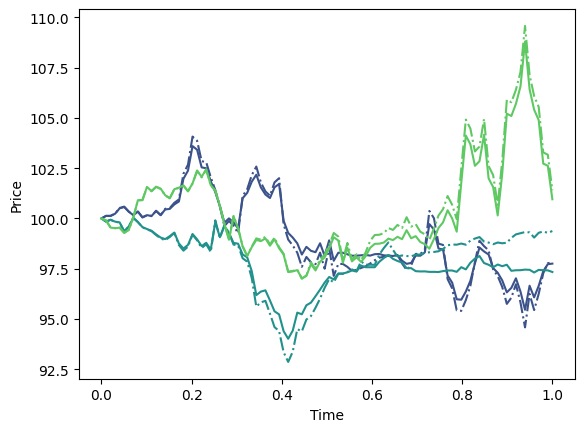

In [51]:
colors = generate_blue_to_red(5)[1:]
for i in range(3):
    plt.plot(time_grid, processes[i, :].T, c=colors[i])
    plt.plot(time_grid, processes_approx[i, :].T, "-.", c=colors[i])
plt.xlabel("Time")
plt.ylabel("Price")
plt.show()

In [52]:
# Pricing with Monte-Carlo simulation
call_price_mc = np.maximum(0, processes[:, -1] - K).mean()
call_price_mc_approx = np.maximum(0, processes_approx[:, -1] - K).mean()

In [ ]:
# Pricing with Fourier inversion 
call_price_fi = european_call_sig(S0, time_grid.max(), K, mrgbm_signature, rho, trunc, rk_subdivs=sim_subdivs, integral_subdivs=integral_subdivs)
call_price_fi_vr = european_call_sig(S0, time_grid.max(), K, mrgbm_signature, rho, trunc, rk_subdivs=sim_subdivs, integral_subdivs=integral_subdivs, r_bs = 0, vol_bs = alpha)

0.27503085136413574


In [54]:
call_price_fi, call_price_mc, call_price_mc_approx, call_price_fi_vr

(10.233895462211507, 10.54346219645062, 10.65964422512152, 10.273186890030644)